<a href="https://colab.research.google.com/github/LCaravaggio/FelicidadDesigualdad/blob/main/Gini%20internet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!wget "https://ookla-open-data.s3.amazonaws.com/shapefiles/performance/type=fixed/year=2020/quarter=2/2020-04-01_performance_fixed_tiles.zip"

--2025-06-06 18:19:54--  https://ookla-open-data.s3.amazonaws.com/shapefiles/performance/type=fixed/year=2020/quarter=2/2020-04-01_performance_fixed_tiles.zip
Resolving ookla-open-data.s3.amazonaws.com (ookla-open-data.s3.amazonaws.com)... 52.92.210.201, 52.92.186.33, 52.92.152.185, ...
Connecting to ookla-open-data.s3.amazonaws.com (ookla-open-data.s3.amazonaws.com)|52.92.210.201|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 173577068 (166M) [application/zip]
Saving to: ‘2020-04-01_performance_fixed_tiles.zip.1’

2020-04-01_performa 100%[===================>] 165.54M  12.5MB/s    in 13s     

2025-06-06 18:20:08 (12.7 MB/s) - ‘2020-04-01_performance_fixed_tiles.zip.1’ saved [173577068/173577068]



In [5]:
!unzip 2020-04-01_performance_fixed_tiles.zip

Archive:  2020-04-01_performance_fixed_tiles.zip
replace gps_fixed_tiles.dbf? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace gps_fixed_tiles.prj? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace gps_fixed_tiles.shp? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [6]:
!pip install simpledbf
from simpledbf import Dbf5
dbf = Dbf5('/content/gps_fixed_tiles.dbf')
df = dbf.to_dataframe()

In [7]:
!pip install pyquadkey2

from pyquadkey2 import quadkey

def qk_to_geo(quadkey_str, zoom_level):
    qk = quadkey.from_str(quadkey_str)
    lat_lon = qk.to_geo(zoom_level)
    return lat_lon


df['geo'] = df['quadkey'].apply(qk_to_geo , zoom_level=1)
df.head()

,quadkey,avg_d_kbps,avg_u_kbps,avg_lat_ms,tests,devices,geo
0,0022133222313202,8630,3638,44,1,1,"(70.64723050859, -159.999389648437)"
1,0022133222330023,597,597,43,1,1,"(70.63630548079, -160.037841796875)"
2,0022133222330203,9183,2949,43,1,1,"(70.632662487073, -160.037841796875)"
3,0022330200132223,4208,4032,27,1,1,"(68.075355907116, -162.850341796875)"
4,0022332201321330,9971,3661,32,1,1,"(66.951575976945, -162.515258789062)"


In [8]:
!pip install mercantile

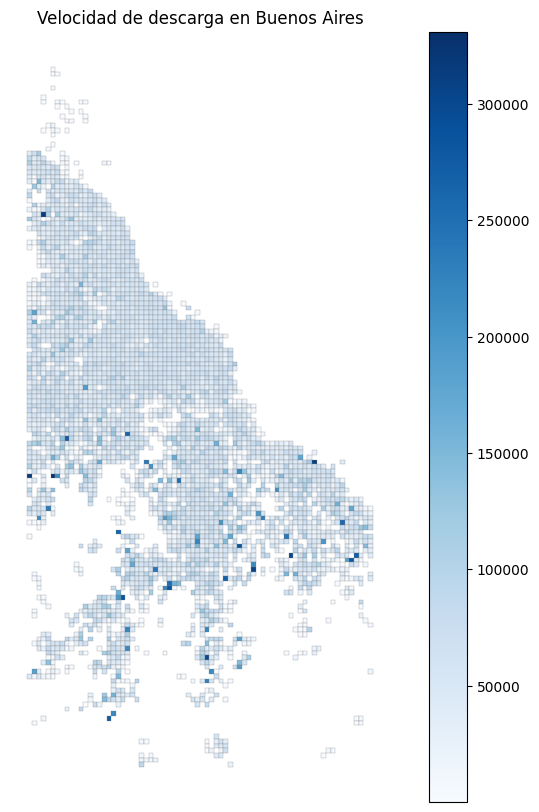

In [9]:
import pandas as pd
import geopandas as gpd
import mercantile
from shapely.geometry import box
import matplotlib.pyplot as plt

# --- Función para convertir quadkey a polígono (en WGS84)
def quadkey_to_polygon(quadkey):
    tile = mercantile.quadkey_to_tile(quadkey)
    bounds = mercantile.bounds(tile)
    return box(bounds.west, bounds.south, bounds.east, bounds.north)

# --- Agregar columna de geometría
df["geometry"] = df["quadkey"].apply(quadkey_to_polygon)

# --- Crear GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")

# --- Filtrar por Buenos Aires (opcional, si hay datos de todo el mundo)
# Buenos Aires aprox: lat -35.0 a -34.3, lon -58.6 a -58.2
gdf_ba = gdf.cx[-58.6:-58.2, -35.0:-34.3]

# --- Plot simple
fig, ax = plt.subplots(figsize=(10, 10))
gdf_ba.plot(column="avg_d_kbps", cmap="Blues", linewidth=0.2, ax=ax, edgecolor='grey', legend=True)
ax.set_title("Velocidad de descarga en Buenos Aires")
plt.axis("off")
plt.show()

In [10]:
import geopandas as gpd

url = "http://cdn.buenosaires.gob.ar/datosabiertos/datasets/barrios/barrios.geojson"
barrios = gpd.read_file(url)  # descarga automática
barrios = barrios.to_crs("EPSG:4326")
print("Barrios cargados:", len(barrios))


Barrios cargados: 48


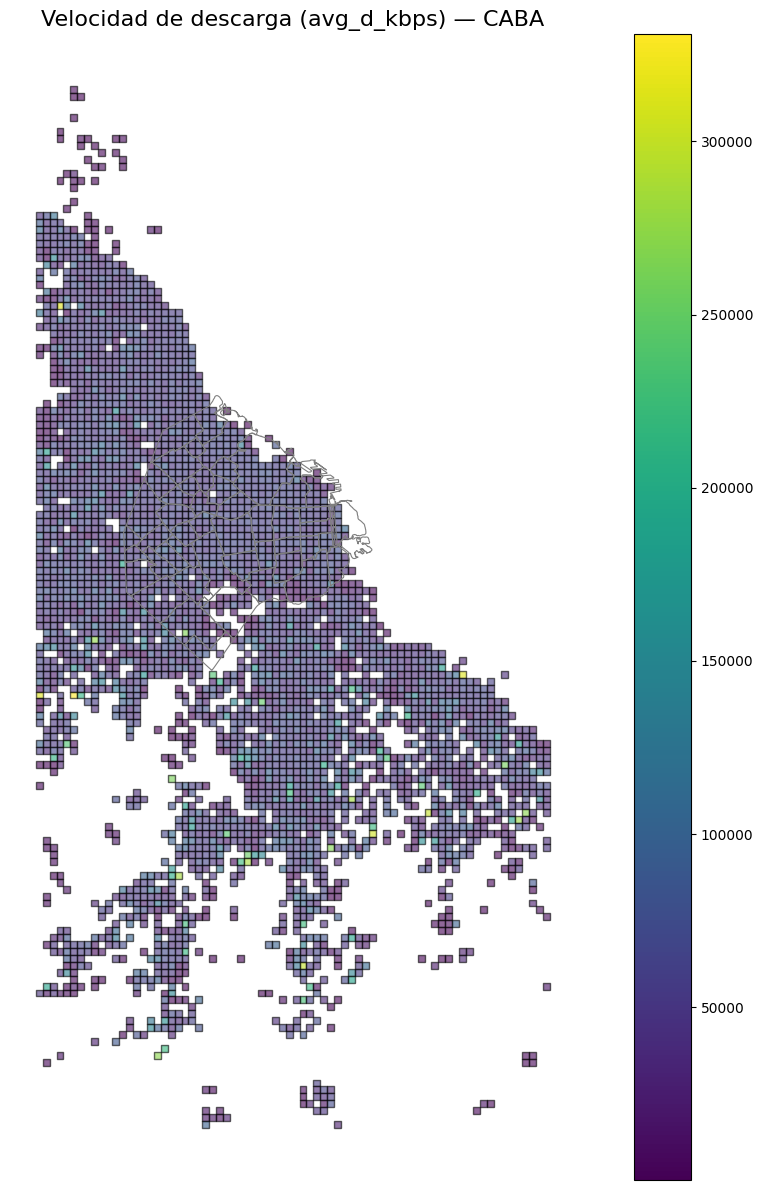

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 12))

# Base de barrios como líneas grises
barrios.boundary.plot(ax=ax, color='gray', linewidth=0.8)

# Tiles coloreados según avg_d_kbps
gdf_ba.plot(ax=ax,
         column="avg_d_kbps",
         cmap="viridis",
         alpha=0.6,
         edgecolor="black",
         legend=True)

ax.set_title("Velocidad de descarga (avg_d_kbps) — CABA", fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.show()

In [12]:
# Asegurar mismo sistema de coordenadas
gdf = gdf.to_crs(barrios.crs)

# Unir todos los barrios en un solo polígono
caba_union = barrios.unary_union

# Filtrar los quadkeys que están dentro del polígono de CABA
gdf_caba = gdf[gdf.geometry.centroid.within(caba_union)]


<ipython-input-12-dacc6de4f32b>:5: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  caba_union = barrios.unary_union
<ipython-input-12-dacc6de4f32b>:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_caba = gdf[gdf.geometry.centroid.within(caba_union)]


In [15]:
import numpy as np

def gini(array):
    array = np.array(array, dtype=np.float64)  # <- conversión explícita
    array = array[~np.isnan(array)]  # eliminar NaNs
    if array.min() < 0:
        array -= array.min()  # desplazamiento si hay negativos
    array += 1e-6  # evitar ceros
    array = np.sort(array)
    n = len(array)
    cumvals = np.cumsum(array)
    return (2 / n) * np.sum((np.arange(1, n+1) * array)) / cumvals[-1] - (n + 1) / n


gini_d = gini(gdf_caba["avg_d_kbps"])


In [16]:
gini_d

np.float64(0.184798349128253)

In [18]:
ciudades=pd.read_csv('base.csv')

In [ ]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
from geopy.distance import geodesic
import numpy as np

# 1. Convertimos el dataframe de puntos a un GeoDataFrame
gdf = gpd.GeoDataFrame(gdf, geometry=gpd.points_from_xy(gdf["geo"].apply(lambda x: x[1]), gdf["geo"].apply(lambda x: x[0])))
gdf.set_crs(epsg=4326, inplace=True)

# 2. Definimos la función de Gini (como antes)
def gini(array):
    array = np.array(array, dtype=np.float64)
    array = array[~np.isnan(array)]
    if len(array) == 0:
        return np.nan
    if array.min() < 0:
        array -= array.min()
    array += 1e-6
    array = np.sort(array)
    n = len(array)
    cumvals = np.cumsum(array)
    return (2 / n) * np.sum((np.arange(1, n + 1) * array)) / cumvals[-1] - (n + 1) / n

# 3. Recorremos cada ciudad y calculamos el Gini en un radio de 10km
resultados = []

for _, row in ciudades.iterrows():
    lat_centro = row["Latitude"]
    lon_centro = row["Longitude"]
    centroide = Point(lon_centro, lat_centro)

    # Filtramos usando una máscara geográfica por distancia
    puntos_cercanos = gdf[gdf.geometry.apply(lambda p: geodesic((p.y, p.x), (lat_centro, lon_centro)).km <= 10)]

    gini_valor = gini(puntos_cercanos["avg_d_kbps"])

    resultados.append({
        "Latitude": lat_centro,
        "Longitude": lon_centro,
        "gini_avg_d_kbps": gini_valor
    })

# 4. Convertimos el resultado en DataFrame
df_ginis = pd.DataFrame(resultados)

# (Opcional) Unimos con el DataFrame de ciudades original si querés conservar más columnas
ciudades_con_gini = pd.merge(ciudades, df_ginis, on=["Latitude", "Longitude"])


In [ ]:
# Guardar el archivo CSV
ciudades_con_gini.to_csv("ciudades_con_gini.csv", index=False)

# Descargar en Colab
from google.colab import files
files.download("ciudades_con_gini.csv")
